# ResNet 50 implementation

In [ ]:
# importing the libraries

from keras.layers import Input, Lambda, Dense, Flatten
from keras.models import Model
from keras.applications.resnet50 import ResNet50
from keras.applications.resnet50 import preprocess_input
from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

### Image Pre-processing

In [ ]:
# re-sizing all the images

IMAGE_SIZE = [224, 224]

train_path = 'Dataset_2/train'
valid_path = 'Dataset_2/test'

In [ ]:
import numpy as np
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define a custom preprocessing function that combines imadjust, Wiener deconvolution, and histogram equalization
def custom_preprocessing(image):
    # 1: Applying imadjust (adjust intensity values)
    in_low = 50
    in_high = 200
    out_low = 0
    out_high = 255
    image = np.interp(image, (in_low, in_high), (out_low, out_high)).astype(np.uint8)

    # Step 2: Apply Wiener deconvolution for image restoration
    psf = np.ones((5, 5)) / 25
    image_restored = cv2.filter2D(image, -1, psf)

    # Step 3: Apply histogram equalization
    if image.shape[-1] == 3:  # Check if the image has 3 channels (RGB)
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    R, G, B = cv2.split(image)

    output1_R = cv2.equalizeHist(R)
    output1_G = cv2.equalizeHist(G)
    output1_B = cv2.equalizeHist(B)

    equalized_image = cv2.merge((output1_R, output1_G, output1_B))
    #equalized_image = cv2.equalizeHist(image_restored)

    return equalized_image

    #image = cv2.imread('path_to_image.jpg', cv2.IMREAD_GRAYSCALE).astype(np.uint8)


In [ ]:
from keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(#preprocessing_function=custom_preprocessing,
                                   rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

#test_datagen = ImageDataGenerator(preprocessing_function=custom_preprocessing,rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

In [ ]:
training_set = train_datagen.flow_from_directory('Dataset_2/train',
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

Found 5216 images belonging to 2 classes.


In [ ]:
test_set = test_datagen.flow_from_directory('Dataset_2/test',
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical')

Found 624 images belonging to 2 classes.


### ResNet 50 model

In [ ]:
# Importing the ResNet 50 library
resnet = ResNet50(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

94765736/94765736 [==============================] - 8s 0us/step


In [ ]:
# not training for existing weights
for layer in resnet.layers:
    layer.trainable = False

In [ ]:
# useful for getting number of output classes
folders = glob('Dataset_2/train/*')

In [ ]:
# our layers - you can add more if you want
x = Flatten()(resnet.output)
x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)

In [ ]:
prediction = Dense(len(folders), activation='softmax')(x)

# create a model object
model = Model(inputs=resnet.input, outputs=prediction)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                          

                                                                                                  
 conv2_block3_1_conv (Conv2  (None, 56, 56, 64)           16448     ['conv2_block2_out[0][0]']    
 D)                                                                                               
                                                                                                  
 conv2_block3_1_bn (BatchNo  (None, 56, 56, 64)           256       ['conv2_block3_1_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv2_block3_1_relu (Activ  (None, 56, 56, 64)           0         ['conv2_block3_1_bn[0][0]']   
 ation)                                                                                           
                                                                                                  
 conv2_blo

 ation)                                                                                           
                                                                                                  
 conv3_block2_3_conv (Conv2  (None, 28, 28, 512)          66048     ['conv3_block2_2_relu[0][0]'] 
 D)                                                                                               
                                                                                                  
 conv3_block2_3_bn (BatchNo  (None, 28, 28, 512)          2048      ['conv3_block2_3_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv3_block2_add (Add)      (None, 28, 28, 512)          0         ['conv3_block1_out[0][0]',    
                                                                     'conv3_block2_3_bn[0][0]']   
          

 conv4_block1_2_conv (Conv2  (None, 14, 14, 256)          590080    ['conv4_block1_1_relu[0][0]'] 
 D)                                                                                               
                                                                                                  
 conv4_block1_2_bn (BatchNo  (None, 14, 14, 256)          1024      ['conv4_block1_2_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv4_block1_2_relu (Activ  (None, 14, 14, 256)          0         ['conv4_block1_2_bn[0][0]']   
 ation)                                                                                           
                                                                                                  
 conv4_block1_0_conv (Conv2  (None, 14, 14, 1024)         525312    ['conv3_block4_out[0][0]']    
 D)       

                                                                                                  
 conv4_block3_out (Activati  (None, 14, 14, 1024)         0         ['conv4_block3_add[0][0]']    
 on)                                                                                              
                                                                                                  
 conv4_block4_1_conv (Conv2  (None, 14, 14, 256)          262400    ['conv4_block3_out[0][0]']    
 D)                                                                                               
                                                                                                  
 conv4_block4_1_bn (BatchNo  (None, 14, 14, 256)          1024      ['conv4_block4_1_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv4_blo

 D)                                                                                               
                                                                                                  
 conv4_block6_3_bn (BatchNo  (None, 14, 14, 1024)         4096      ['conv4_block6_3_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv4_block6_add (Add)      (None, 14, 14, 1024)         0         ['conv4_block5_out[0][0]',    
                                                                     'conv4_block6_3_bn[0][0]']   
                                                                                                  
 conv4_block6_out (Activati  (None, 14, 14, 1024)         0         ['conv4_block6_add[0][0]']    
 on)                                                                                              
          

 conv5_block3_1_relu (Activ  (None, 7, 7, 512)            0         ['conv5_block3_1_bn[0][0]']   
 ation)                                                                                           
                                                                                                  
 conv5_block3_2_conv (Conv2  (None, 7, 7, 512)            2359808   ['conv5_block3_1_relu[0][0]'] 
 D)                                                                                               
                                                                                                  
 conv5_block3_2_bn (BatchNo  (None, 7, 7, 512)            2048      ['conv5_block3_2_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv5_block3_2_relu (Activ  (None, 7, 7, 512)            0         ['conv5_block3_2_bn[0][0]']   
 ation)   

In [ ]:
# compiling the model
model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

### Training the model and evaluating it

In [ ]:
# Training the CNN on the training set and evaluating it on the Test set

r = model.fit(
  x=training_set,
  validation_data=test_set,
  epochs=20,
  steps_per_epoch=len(training_set),
  validation_steps=len(test_set)
)

Epoch 1/20
163/163 [==============================] - 531s 3s/step - loss: 0.7115 - accuracy: 0.7414 - val_loss: 0.4918 - val_accuracy: 0.7388
Epoch 2/20
163/163 [==============================] - 510s 3s/step - loss: 0.3849 - accuracy: 0.8229 - val_loss: 0.9062 - val_accuracy: 0.6667
Epoch 3/20
163/163 [==============================] - 514s 3s/step - loss: 0.3007 - accuracy: 0.8660 - val_loss: 0.4177 - val_accuracy: 0.8141
Epoch 4/20
163/163 [==============================] - 514s 3s/step - loss: 0.2955 - accuracy: 0.8702 - val_loss: 0.3709 - val_accuracy: 0.8285
Epoch 5/20
163/163 [==============================] - 503s 3s/step - loss: 0.2580 - accuracy: 0.8896 - val_loss: 0.3267 - val_accuracy: 0.8734
Epoch 6/20
163/163 [==============================] - 506s 3s/step - loss: 0.2401 - accuracy: 0.9003 - val_loss: 0.3896 - val_accuracy: 0.8413
Epoch 7/20
163/163 [==============================] - 503s 3s/step - loss: 0.2297 - accuracy: 0.9066 - val_loss: 0.3543 - val_accuracy: 0.8526

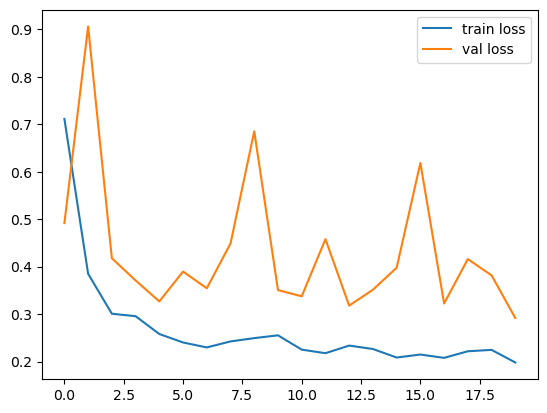

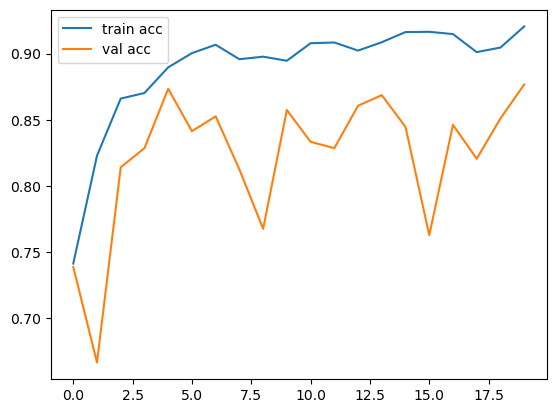

<Figure size 640x480 with 0 Axes>

In [ ]:
# plot the loss
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

# plot the accuracy
plt.plot(r.history["accuracy"], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

### Making a single prediction

In [ ]:
import numpy as np
from keras.preprocessing import image


test_image = image.load_img('Dataset_2/val/NORMAL/NORMAL2-IM-1406-0001.jpeg', target_size = (224,224))
#test_image = image.load_img('Dataset_2/val/PNEUMONIA/person1946_bacteria_4874.jpeg', target_size = (224,224))
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis = 0)

result = model.predict(test_image)

print(result)
training_set.class_indices
if result[0][0]< result[0][1]:
    prediction = 'pneumonia'
else:
    prediction = 'normal'

print(prediction)

1/1 [==============================] - 0s 109ms/step
[[1.1986403e-09 1.0000000e+00]]
pneumonia


In [ ]:
# saving the model

import tensorflow as tf

from keras.models import load_model

model.save('model_resnet_50.keras')